In [1]:
from Observation import *
from reduction_tools import *

import os
import numpy as np
from astropy.io import fits

from matplotlib import pyplot as plt
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import LogNorm

colors = iter([plt.cm.Set1(i) for i in range(20)])
default_cycler = cycler(color=colors)
plt.rc('axes', prop_cycle=default_cycler)

font = {'size'   : 22}
mpl.rc('font', **font)

Here is a basic tutorial on how to use this EMIR GTC pipeline to generate a response curve. This pipeline has the same steps as the general example (see OB0011_example.ipynb) until step 4:

1. Object and File System Initialization
2. Rectification and Calibration
3. ABBA Subtraction
4. __Make & Save Response Curve__

Step 1-3 are outlined and explained in the OB0011 example, so they are done without expalation in the next box. After, we will explain step 4.

In [2]:
o = Observation("OB0012")
 
if not os.path.exists('OB0012/results/ABBA/ABBA_subtracted_YJ.fits'):
    o.initialize('object', 'YJ')
    o.rectify_and_analyze('object','YJ')
    o.ABBA_subtract('YJ')

To generate the response curve, you need to have the tabulated spectrum for the star you are using. It doesn't have to have wavelengths that match your data, as we will be interpolating the response curve to fit the data. In this example, the tabulated spectrum is a generic A0V star, so we are using a generic A0V spectrum, stored in `OB0012/uka0v.fits`.

Here is some documentation on the function call and what options you can use:

__`Observation.make_response_curve(tabulated_spectrum_path, filter_type, **kwargs)`__

Makes and saves the response curve given a tabulated spectrum.

Arguments:

- `tabulated_spectrum_path (str)`: path to the tabulated spectrum (only fits files with wavelength calibration information in the header are supported)
- `filter_type (str)`: the GRISM you want to analyze (options: J, YJ, HK, etc. depending on your quality control file)
- `SN_position` (`tuple` or `int`): a tuple of length 2 to specify which y-axis pixels the positive and negative ABBA results are respectively, or an integer with the approximate position of the A and B positions.
- `correct_telluric_lines (bool)`: flag to correct telluric lines. Default: `True`
- `prelim_smooth_radius (int)`: smooth radius for the response curve between the intial and telluric correction steps. Default: `None`
- `telluric_smooth_radius (int)`: smooth radius for the response curve after the telluric correction. Default: `None`
- `raw_debug` (`bool`): flag to output extra information about the raw data selection (launches a matpotlib plot)

Returns:
- None
- Saves the raw 1D spectrum to: `results/response_curve_dir/[filter]_spectrum_raw.fits`
- Saves preliminary response curve to `results/response_curve_dir/[filter]_response_curve.fits`
- Saves telluric response curve to `results/response_curve_dir/[filter]_response_curve_telluric_corr.fits`


Now let's actually make the response curve and see what happens:

In [3]:
o.make_response_curve('OB0012/uka0v.fits', 'YJ')

In [4]:
os.listdir('OB0012/results/response_curve/')

['YJ_response_curve.fits',
 'HK_spectrum_raw.fits',
 'YJ_splined_response.fits',
 'HK_response_curve.fits',
 'YJ_spectrum_raw.fits',
 'YJ_response_curve_telluric_corr.fits',
 'HK_splined_response.fits',
 'HK_response_curve_telluric_corr.fits']

Let's make some plots so you can mess around with the parameters:

In [5]:
def plot_it(wave, y_axis, title):
        
    plt.plot(wave, y_axis)
    plt.gcf().set_size_inches((20,5))
    plt.title(title)
    
    plt.show()
    
def plot_raw(title, **kwargs):
    wave, counts = o.get_raw_spectrum('YJ', **kwargs)
    title = "Raw Data, %s"%title
    
    plt.ylabel('Counts')
    plot_it(wave, counts, title)
    
def plot_response_curve(title):
    wave, resp = o.get_response_curve('YJ')
    title = "Response Curve, %s"%title
    
    plt.ylabel('Flux/Counts')
    plot_it(wave, resp, title)

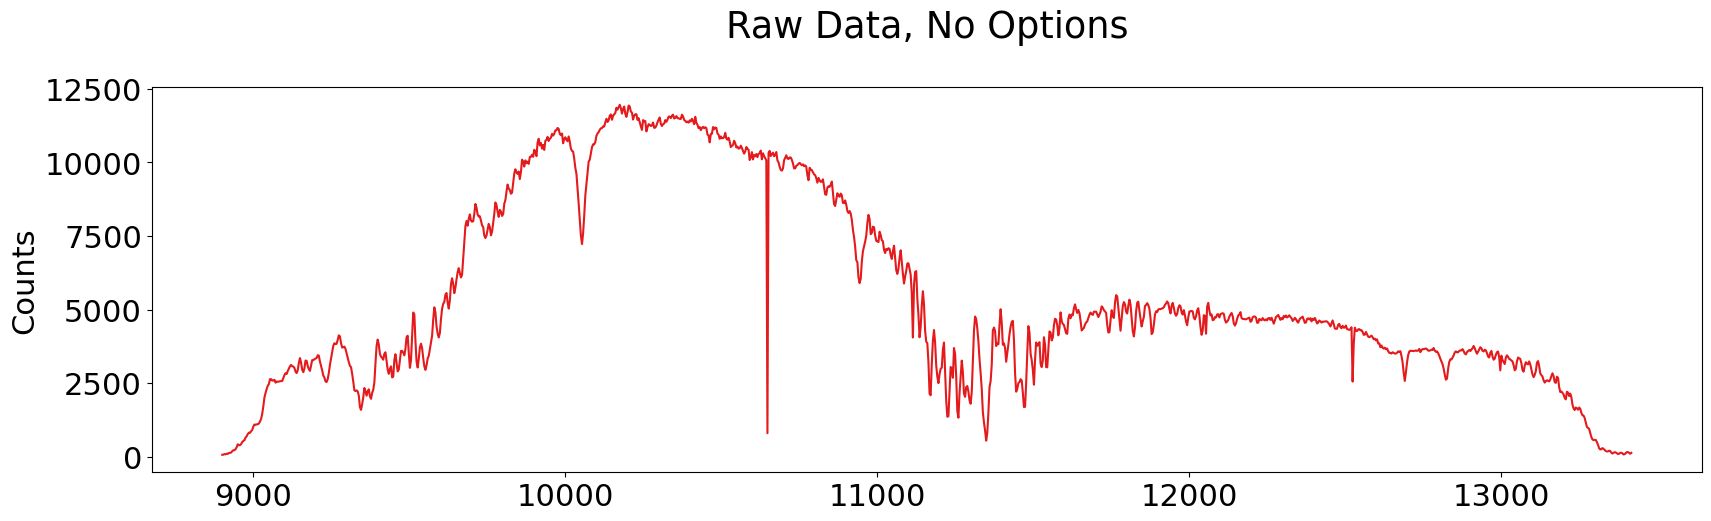

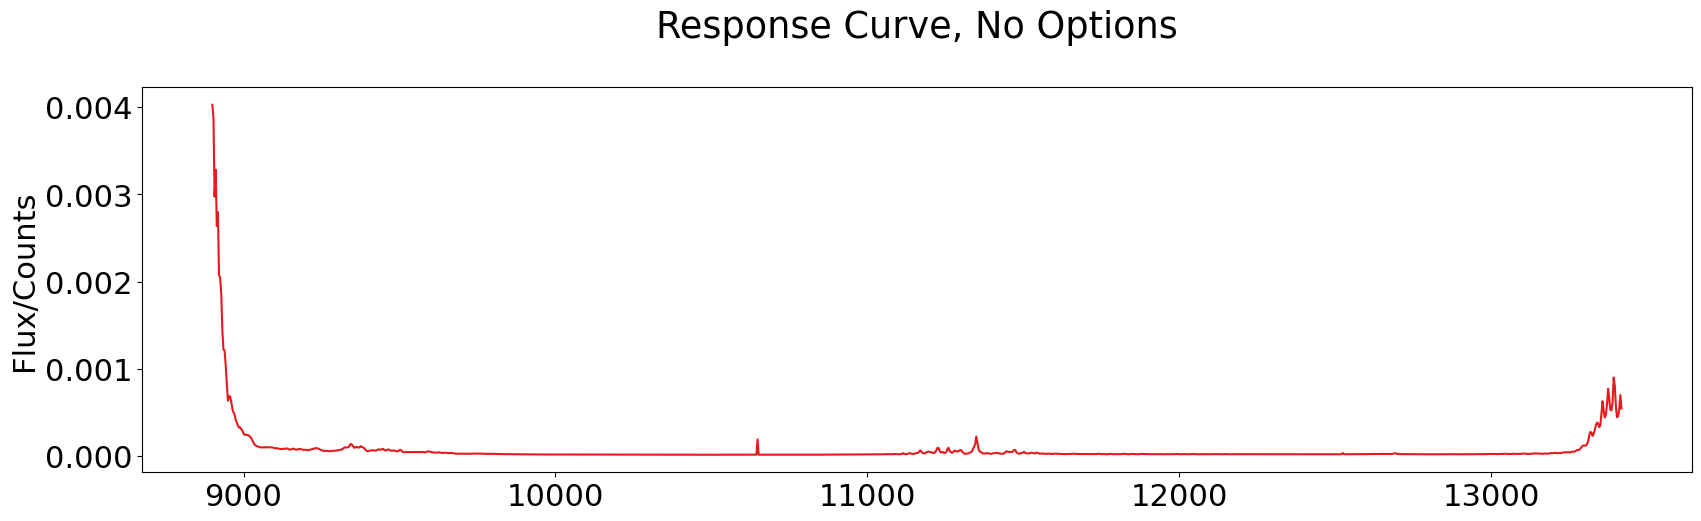

In [6]:
plot_raw("No Options\n")
plot_response_curve("No Options\n")